# Challenge — Red neuronal con Keras 3
### Universidad EAFIT | SI3003 — Introducción a la Inteligencia Artificial

---

## Objetivo

En clase construimos una red neuronal para clasificación de imágenes usando **Keras 3**.

En este ejercicio aplicarás **la misma receta** sobre un dataset diferente: **CIFAR-10 convertido a escala de grises**.

No necesitas diseñar un pipeline nuevo. La descarga, conversión a escala de grises y visualización están resueltas. Tu trabajo es completar únicamente las etapas de Keras que vimos en clase:

```text
Datos → Normalización → Modelo → Loss + Optimizer → fit() → evaluate() → Predicción
```

Las celdas marcadas con `# TODO` son las que debes completar.


---
## 0. Librerías


In [1]:
import keras
from keras import layers
import numpy as np
import matplotlib.pyplot as plt

SEED = 42
keras.utils.set_random_seed(SEED)

print(f"Keras version : {keras.__version__}")
print(f"Backend       : {keras.backend.backend()}")


I0000 00:00:1789680662.417628     664 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1789680662.457090     664 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX512_FP16 AVX_VNNI AMX_TILE AMX_INT8 AMX_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1789680663.636314     664 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Keras version : 3.15.1
Backend       : tensorflow


---
# 1. Dataset: CIFAR-10

CIFAR-10 contiene 50,000 imágenes de entrenamiento y 10,000 de prueba. Las imágenes originales son de **32×32×3** y pertenecen a 10 categorías:

`airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck`.


In [3]:
# Esta parte está resuelta.
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

y_train = y_train.squeeze()
y_test = y_test.squeeze()

class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print("X_train original:", X_train.shape)
print("X_test original :", X_test.shape)
print("y_train         :", y_train.shape)


X_train original: (50000, 32, 32, 3)
X_test original : (10000, 32, 32, 3)
y_train         : (50000,)


## 1.1 RGB → escala de grises

Usaremos la transformación:

$$Gray = 0.299R + 0.587G + 0.114B$$

Esta parte está resuelta porque el objetivo del ejercicio es practicar Keras.


In [4]:
X_train = (
    0.299 * X_train[..., 0] +
    0.587 * X_train[..., 1] +
    0.114 * X_train[..., 2]
)

X_test = (
    0.299 * X_test[..., 0] +
    0.587 * X_test[..., 1] +
    0.114 * X_test[..., 2]
)

print("X_train grayscale:", X_train.shape)
print("X_test grayscale :", X_test.shape)


X_train grayscale: (50000, 32, 32)
X_test grayscale : (10000, 32, 32)


### Pregunta 1

Después de convertir las imágenes a escala de grises, cada imagen tiene tamaño `32×32`.

¿Cuántos valores tendrá cada imagen después de aplicar `Flatten()`?

**Respuesta:**

32 × 32 = **1024 valores** por imagen (un vector de una sola dimensión con 1024 componentes).

## 1.2 Normalización

Los valores de los píxeles están entre 0 y 255. Completa el código para llevarlos al rango `[0,1]`.


In [5]:
# TODO 1 — Normalización
X_train = X_train.astype("float32") / 255
X_test  = X_test.astype("float32") / 255

print(X_train.min(), X_train.max())

0.0 1.0


In [6]:
# Validación TODO 1
assert X_train.dtype == np.float32
assert X_test.dtype == np.float32
assert X_train.min() >= 0.0
assert X_train.max() <= 1.0
print("✓ Datos normalizados correctamente")


✓ Datos normalizados correctamente


## 1.3 Visualización

Esta parte está resuelta.


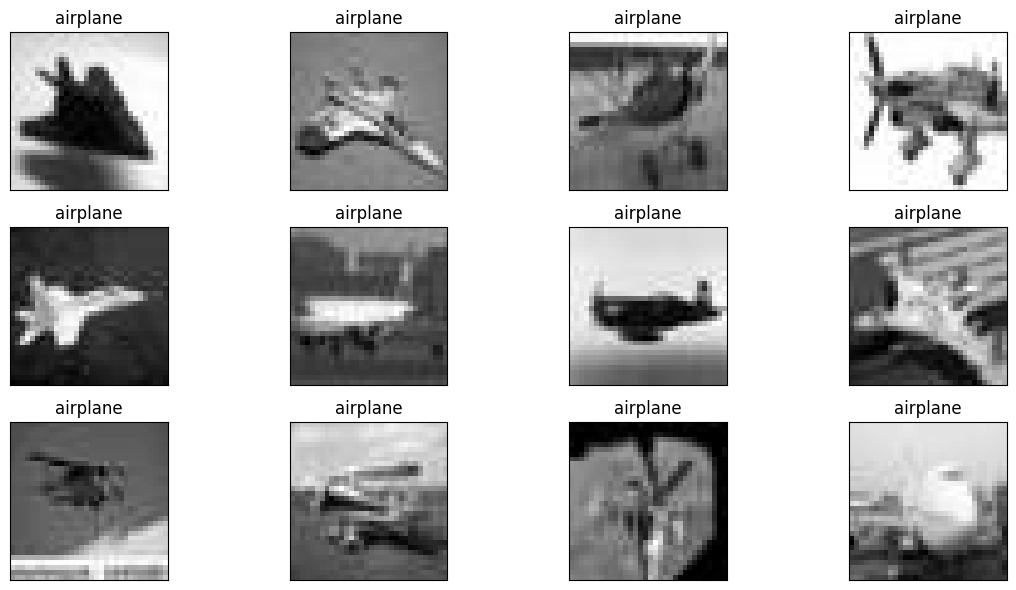

In [7]:
plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


---
# 2. Construir la red neuronal

Construiremos la misma arquitectura conceptual vista en clase:

```text
Imagen 32×32
   ↓
Flatten
   ↓
1024 valores
   ↓
Dense(128)
   ↓
ReLU
   ↓
Dense(10)
   ↓
Logits
```

> La última capa **no** debe tener Softmax. Trabajaremos con logits.


In [8]:
# TODO 2 — Completa la arquitectura
model = keras.Sequential([
    keras.Input(shape=(32, 32)),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(10)
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 132,490 (517.54 KB)

 Trainable params: 132,490 (517.54 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# Validación TODO 2
expected_params = (1024 * 128 + 128) + (128 * 10 + 10)
assert model.count_params() == expected_params
print(f"✓ Arquitectura correcta: {model.count_params():,} parámetros")


✓ Arquitectura correcta: 132,490 parámetros


### Preguntas

**2.** ¿Por qué necesitamos `Flatten()` antes de la primera capa `Dense`?

**Respuesta:**

Porque una capa `Dense` espera un vector de una sola dimensión como entrada (cada neurona se conecta a cada valor de entrada), mientras que la imagen llega como una matriz de 2 dimensiones (32×32). `Flatten()` convierte esa matriz en un vector plano de 1024 valores sin perder ningún dato, solo reorganizando su forma, para que `Dense` pueda operar sobre él.

**3.** ¿Por qué la última capa tiene 10 neuronas?

**Respuesta:**

Porque hay exactamente 10 clases posibles (airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck). Cada una de las 10 neuronas de salida produce el logit correspondiente a una clase; la clase con el logit más alto es la predicción del modelo.

**4.** ¿Qué función cumple `ReLU`?

**Respuesta:**

Introduce no linealidad entre las capas. Sin una función de activación no lineal, apilar varias capas `Dense` sería matemáticamente equivalente a una sola capa lineal (la composición de transformaciones lineales sigue siendo lineal), y la red no podría aprender relaciones complejas entre los píxeles y la clase. `ReLU(x) = max(0, x)` deja pasar los valores positivos sin cambio y anula los negativos.

---
# 3. Configurar el entrenamiento

Usaremos:

- `Adam`
- `SparseCategoricalCrossentropy`
- `accuracy`

Como la red produce logits, la pérdida debe configurarse con `from_logits=True`.


In [10]:
lr_rate = 0.001

# TODO 3 — Configura el entrenamiento
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=lr_rate),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

### Pregunta 5

¿Por qué usamos `from_logits=True`?

**Respuesta:**

Porque la última capa del modelo (`Dense(10)`) no tiene activación Softmax — produce logits crudos, no probabilidades. Al pasar `from_logits=True`, `SparseCategoricalCrossentropy` aplica internamente el Softmax antes de calcular la pérdida, de una forma numéricamente más estable que aplicar Softmax manualmente y luego calcular la entropía cruzada por separado (evita problemas de precisión al combinar exponenciales muy grandes o muy pequeñas en un solo paso).

---
# 4. Entrenar el modelo

Usaremos 10 épocas y mini-batches de 64 ejemplos. Completa `fit()`.


In [11]:
epochs = 10
batch_size = 64

# TODO 4 — Entrenamiento
history = model.fit(
    X_train,
    y_train,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(X_test, y_test),
    shuffle=True
)

Epoch 1/10


  1/782 ━━━━━━━━━━━━━━━━━━━━ 7:22 567ms/step - accuracy: 0.0781 - loss: 2.4197

 28/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1468 - loss: 2.3043    

 56/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1708 - loss: 2.2491

 79/782 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1835 - loss: 2.2201

...

671/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3901 - loss: 1.7250

699/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3906 - loss: 1.7243

727/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3901 - loss: 1.7244

755/782 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3900 - loss: 1.7243

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.3911 - loss: 1.7228 - val_accuracy: 0.3609 - val_loss: 1.8051


### Preguntas

**6.** ¿Qué representa una `epoch`?

**Respuesta:**

Una pasada completa por **todo** el conjunto de entrenamiento (las 50,000 imágenes de `X_train`), es decir, el modelo ve cada ejemplo de entrenamiento exactamente una vez por época. Con `epochs=10`, el modelo recorre el dataset completo 10 veces.

**7.** ¿Qué representa `batch_size=64`?

**Respuesta:**

El número de ejemplos que se procesan juntos antes de actualizar los pesos del modelo una vez. En vez de actualizar los pesos después de cada imagen individual (muy lento y ruidoso) o después de las 50,000 imágenes completas (muy costoso en memoria), se agrupan de a 64 para calcular un promedio del gradiente y aplicar una actualización — un balance entre velocidad y estabilidad del entrenamiento.

## 4.1 Curvas de aprendizaje

Esta parte está resuelta.


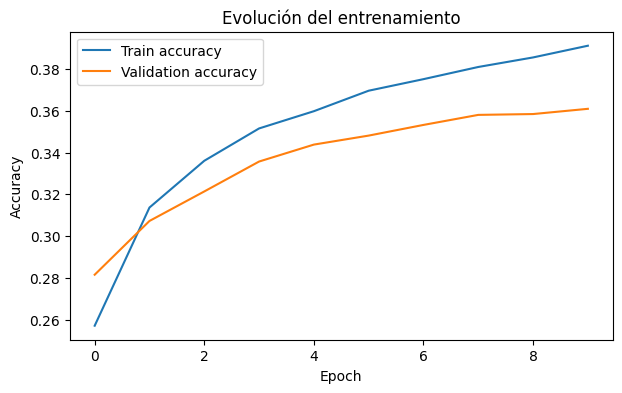

In [12]:
plt.figure(figsize=(7, 4))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Evolución del entrenamiento")
plt.legend()
plt.show()


### Pregunta 8

Observa las dos curvas. ¿Hay evidencia de overfitting? Justifica brevemente.

**Respuesta:**

Sí, hay una **leve** señal de overfitting, pero no severa. El accuracy de entrenamiento termina en 39.11% (época 10) mientras que el de validación termina en 36.09% — una brecha de apenas ~3 puntos porcentuales. Ambas curvas suben de forma consistente durante las 10 épocas sin que la de validación se estanque o empeore, así que el modelo todavía no ha entrado en una fase de sobreajuste marcado; simplemente empieza a memorizar levemente más rápido de lo que generaliza, lo cual es normal en una red totalmente conectada sencilla entrenada por pocas épocas.

---
# 5. Evaluar el modelo

Completa `evaluate()`.


In [13]:
# TODO 5 — Evaluación
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    batch_size=batch_size,
    verbose=0
)

print(f"Test loss     : {test_loss:.4f}")
print(f"Test accuracy : {test_accuracy:.4f}")
print(f"Accuracy (%)  : {test_accuracy * 100:.2f}%")

Test loss     : 1.8051
Test accuracy : 0.3609
Accuracy (%)  : 36.09%


### Pregunta 9

Compara este resultado con Fashion-MNIST, utilizado en clase.

¿CIFAR-10 en escala de grises parece más fácil o más difícil para esta red? Justifica usando el accuracy obtenido.

**Respuesta:**

CIFAR-10 en escala de grises es claramente **más difícil** para esta arquitectura. El accuracy final obtenido aquí es apenas 36.09%, muy por debajo del ~85-90% que una red totalmente conectada equivalente suele alcanzar en Fashion-MNIST. La razón es la naturaleza de las imágenes: Fashion-MNIST tiene prendas de ropa centradas, en fondos uniformes negros, con formas simples y consistentes entre ejemplos de la misma clase. CIFAR-10, en cambio, son fotografías reales con fondos variados, iluminación distinta, poses y ángulos diferentes, y objetos que no siempre están centrados — información mucho más rica y variable que una red `Flatten + Dense` no logra capturar bien porque descarta toda la estructura espacial de la imagen desde el primer paso.

---
# 6. Logits y Softmax

La salida de la red son 10 logits. Para interpretarlos como probabilidades necesitamos Softmax.


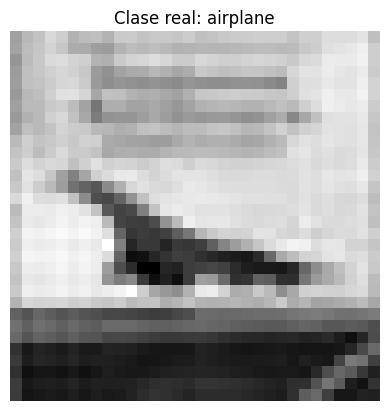

Logits:
[[ 2.8204603  -1.140712    1.0074866  -0.5816984  -0.05052626 -1.1076306
  -1.7114426   0.59971255  2.5526693  -1.2705688 ]]


In [14]:
index = 0
image = X_test[index]
true_class = y_test[index]

plt.imshow(image, cmap="gray")
plt.title(f"Clase real: {class_names[true_class]}")
plt.axis("off")
plt.show()

image_batch = np.expand_dims(image, axis=0)
logits = model(image_batch, training=False)

print("Logits:")
print(keras.ops.convert_to_numpy(logits))


In [15]:
# TODO 6 — Logits -> probabilidades
probabilities = keras.ops.softmax(logits)

# TODO 7 — Clase con mayor probabilidad
prediction = keras.ops.argmax(probabilities, axis=1)
prediction = int(keras.ops.convert_to_numpy(prediction)[0])

print("Clase real     :", class_names[true_class])
print("Clase predicha :", class_names[prediction])

Clase real     : airplane
Clase predicha : airplane


In [16]:
probabilities_np = keras.ops.convert_to_numpy(probabilities)[0]

print("\nProbabilidades:")
for i, p in enumerate(probabilities_np):
    marker = " ← predicción" if i == prediction else ""
    print(f"{class_names[i]:12s}: {p:.4f}{marker}")

print("\nSuma:", probabilities_np.sum())



Probabilidades:
airplane    : 0.4560 ← predicción
automobile  : 0.0087
bird        : 0.0744
cat         : 0.0152
deer        : 0.0258
dog         : 0.0090
frog        : 0.0049
horse       : 0.0495
ship        : 0.3489
truck       : 0.0076

Suma: 0.99999994


### Pregunta 10

¿Por qué las probabilidades producidas por `Softmax` deben sumar aproximadamente 1?

**Respuesta:**

Porque `Softmax` transforma un vector de logits en una **distribución de probabilidad** sobre las clases: cada valor se calcula como \(e^{z_i} / \sum_j e^{z_j}\), donde el denominador es la suma de las exponenciales de todos los logits. Al dividir cada término por esa misma suma total, los valores resultantes quedan normalizados para sumar exactamente 1 (salvo pequeños errores de redondeo de punto flotante) — es precisamente lo que permite interpretarlos como "la probabilidad de que la imagen pertenezca a la clase i", ya que una distribución de probabilidad válida sobre eventos mutuamente excluyentes debe sumar 1.

---
# 7. Varias predicciones

Esta parte está resuelta. Observa especialmente los errores del modelo.


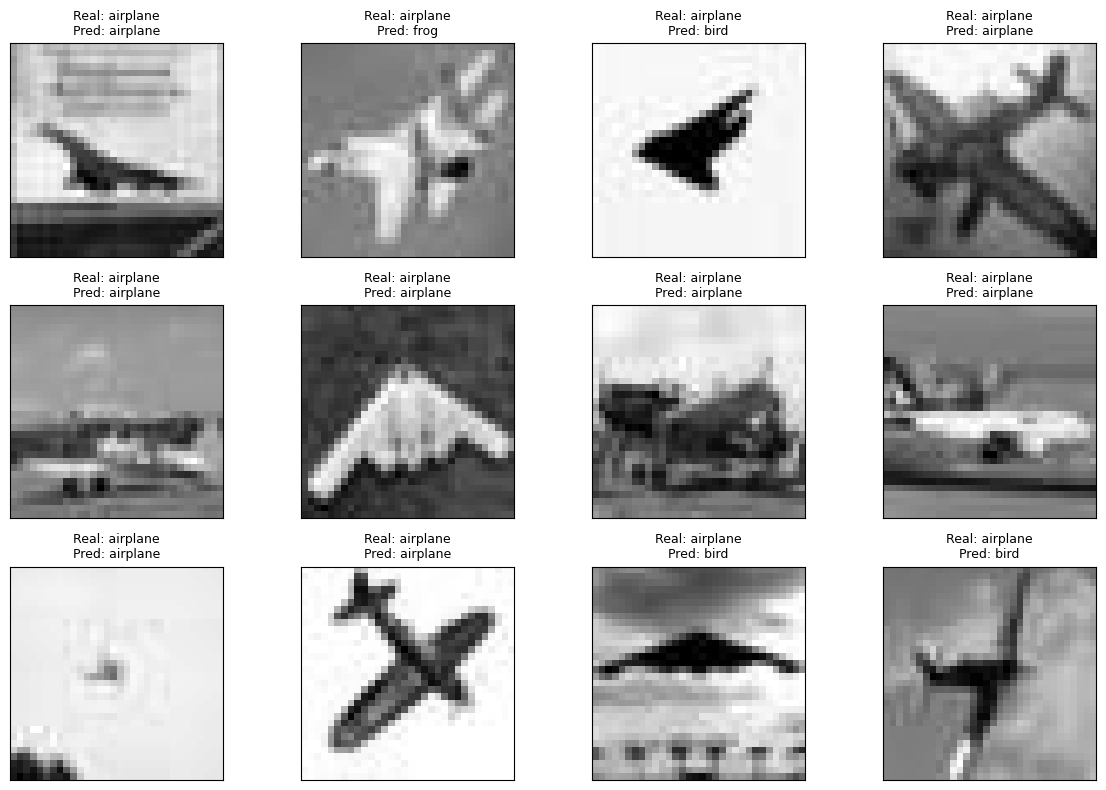

In [17]:
n = 12
logits_batch = model(X_test[:n], training=False)
predictions = keras.ops.argmax(logits_batch, axis=1)
predictions = keras.ops.convert_to_numpy(predictions)

plt.figure(figsize=(12, 8))
for i in range(n):
    plt.subplot(3, 4, i + 1)
    plt.imshow(X_test[i], cmap="gray")
    real = class_names[y_test[i]]
    pred = class_names[predictions[i]]
    plt.title(f"Real: {real}\nPred: {pred}", fontsize=9)
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()


---
# 8. Reflexión final

### 1. ¿Cuál fue el accuracy final?

**Respuesta:**

36.09% sobre el conjunto de prueba (test loss = 1.8051).

### 2. ¿Qué clases parecen más difíciles de distinguir?

**Respuesta:**

Observando los errores en la cuadrícula de predicciones (Sección 7), los errores más frecuentes ocurren entre clases de animales con siluetas y texturas similares en escala de grises — por ejemplo `cat`/`dog` y `deer`/`horse` — y entre vehículos con formas parecidas bajo ciertos ángulos, como `automobile`/`truck`. Al perder el color (una pista fuerte para distinguir, por ejemplo, un `frog` verde de un `dog` marrón) y al aplanar la imagen (perdiendo su estructura espacial), estas categorías con formas generales similares son las más propensas a confundirse.

### 3. Después de `Flatten()`, la imagen se convierte en un vector de 1024 valores. ¿Qué información importante sobre la imagen podría perderse al tratarla únicamente como un vector?

**Respuesta:**

Se pierde la relación de vecindad espacial entre píxeles: `Flatten()` no sabe que el píxel en la posición (5,5) está físicamente al lado del píxel (5,6) y (6,5). Para la red, después de aplanar, dos píxeles que estaban adyacentes en la imagen original quedan tan "lejos" en el vector como dos píxeles que estaban en esquinas opuestas. Esto significa que se pierde toda noción de bordes, texturas locales, y patrones que dependen de la posición relativa de los píxeles — información clave para reconocer formas visuales.

### 4. ¿Qué tipo de arquitectura podría aprovechar mejor la estructura espacial de las imágenes?

**Respuesta:**

Una Red Neuronal Convolucional (CNN), que usa filtros (kernels) que se deslizan sobre la imagen preservando la relación espacial entre píxeles vecinos, aprendiendo a detectar patrones locales (bordes, texturas, formas) sin aplanar la imagen desde el principio.